# Install & Import Libraries

In [ ]:
!pip install roboflow
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install Ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 136.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.6 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
from ctypes import BigEndianStructure
from ultralytics import YOLO
from IPython.display import Image as IPyImage, display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
from ipywidgets import HBox, Image as WImage
import base64

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Import Dataset

In [ ]:
rf = Roboflow(api_key="YBaBoieNSNnA7fkaAghG")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(4)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-4 in yolov11:: 100%|██████████| 48488/48488 [00:06<00:00, 7417.94it/s]


# Model Training


In [ ]:
model = YOLO("yolo12n.pt")
train_results = model.train(
    data="/content/License-Plate-Recognition-4/data.yaml",
    epochs=100,
    imgsz=640,
    batch=64,
    patience=8,
    lr0=0.001,
    optimizer="AdamW",
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=8, perspective=0.0,

# Model Evaluation

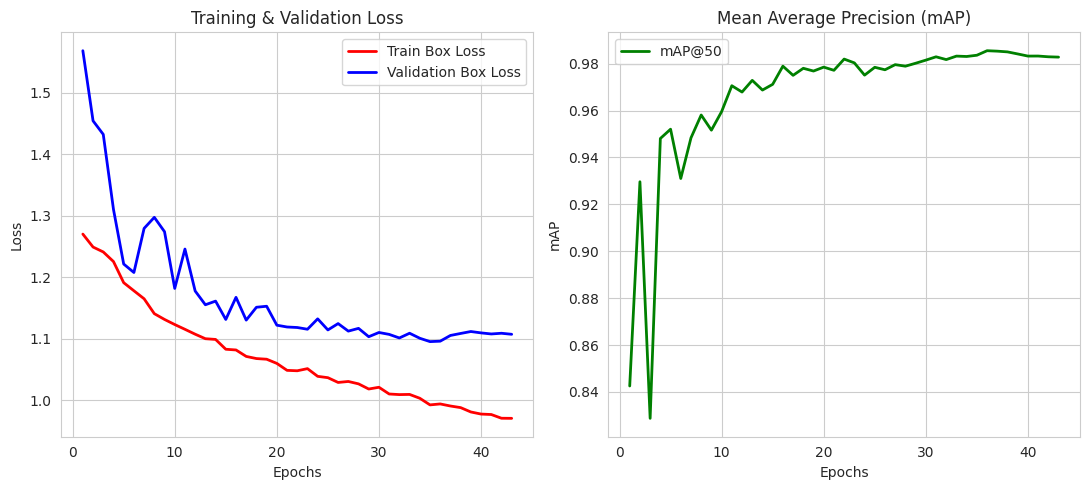

In [ ]:
df = pd.read_csv('/content/runs/detect/train/results.csv')


map_column = "metrics/mAP50(B)"
loss_column_train = "train/box_loss"
loss_column_val = "val/box_loss"

plt.figure(figsize=(11,5))

sns.set_style("whitegrid")

plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df[loss_column_train], label="Train Box Loss", color="red", linewidth=2)
plt.plot(df["epoch"], df[loss_column_val], label="Validation Box Loss", color="blue", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df[map_column], label="mAP@50", color="green", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("Mean Average Precision (mAP)")
plt.legend()

plt.tight_layout()

plt.show()

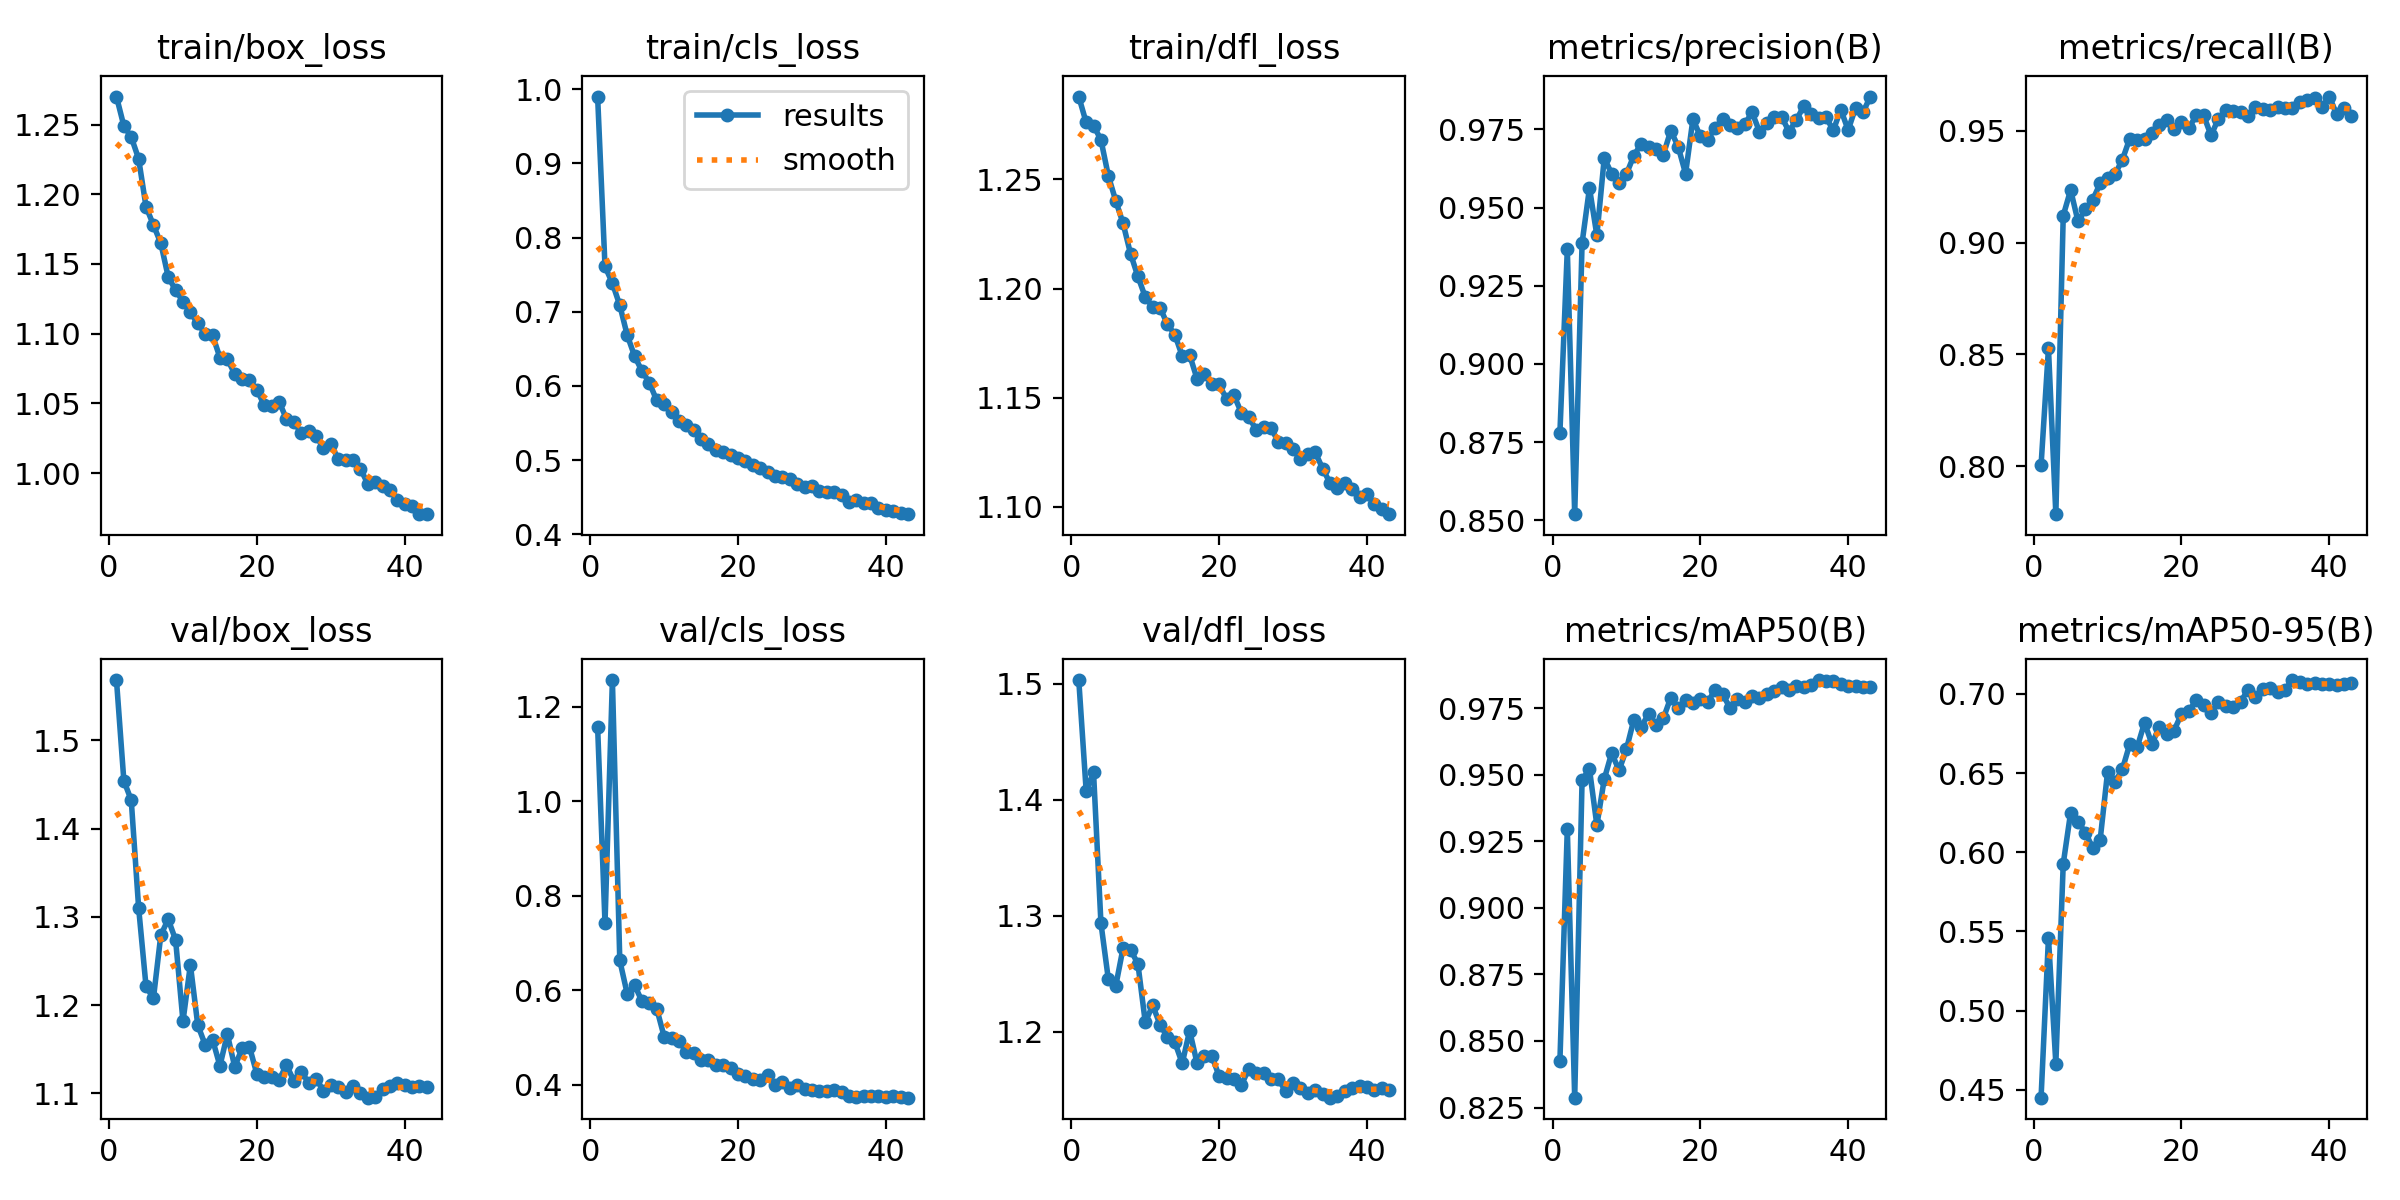

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/results.png', width=900)

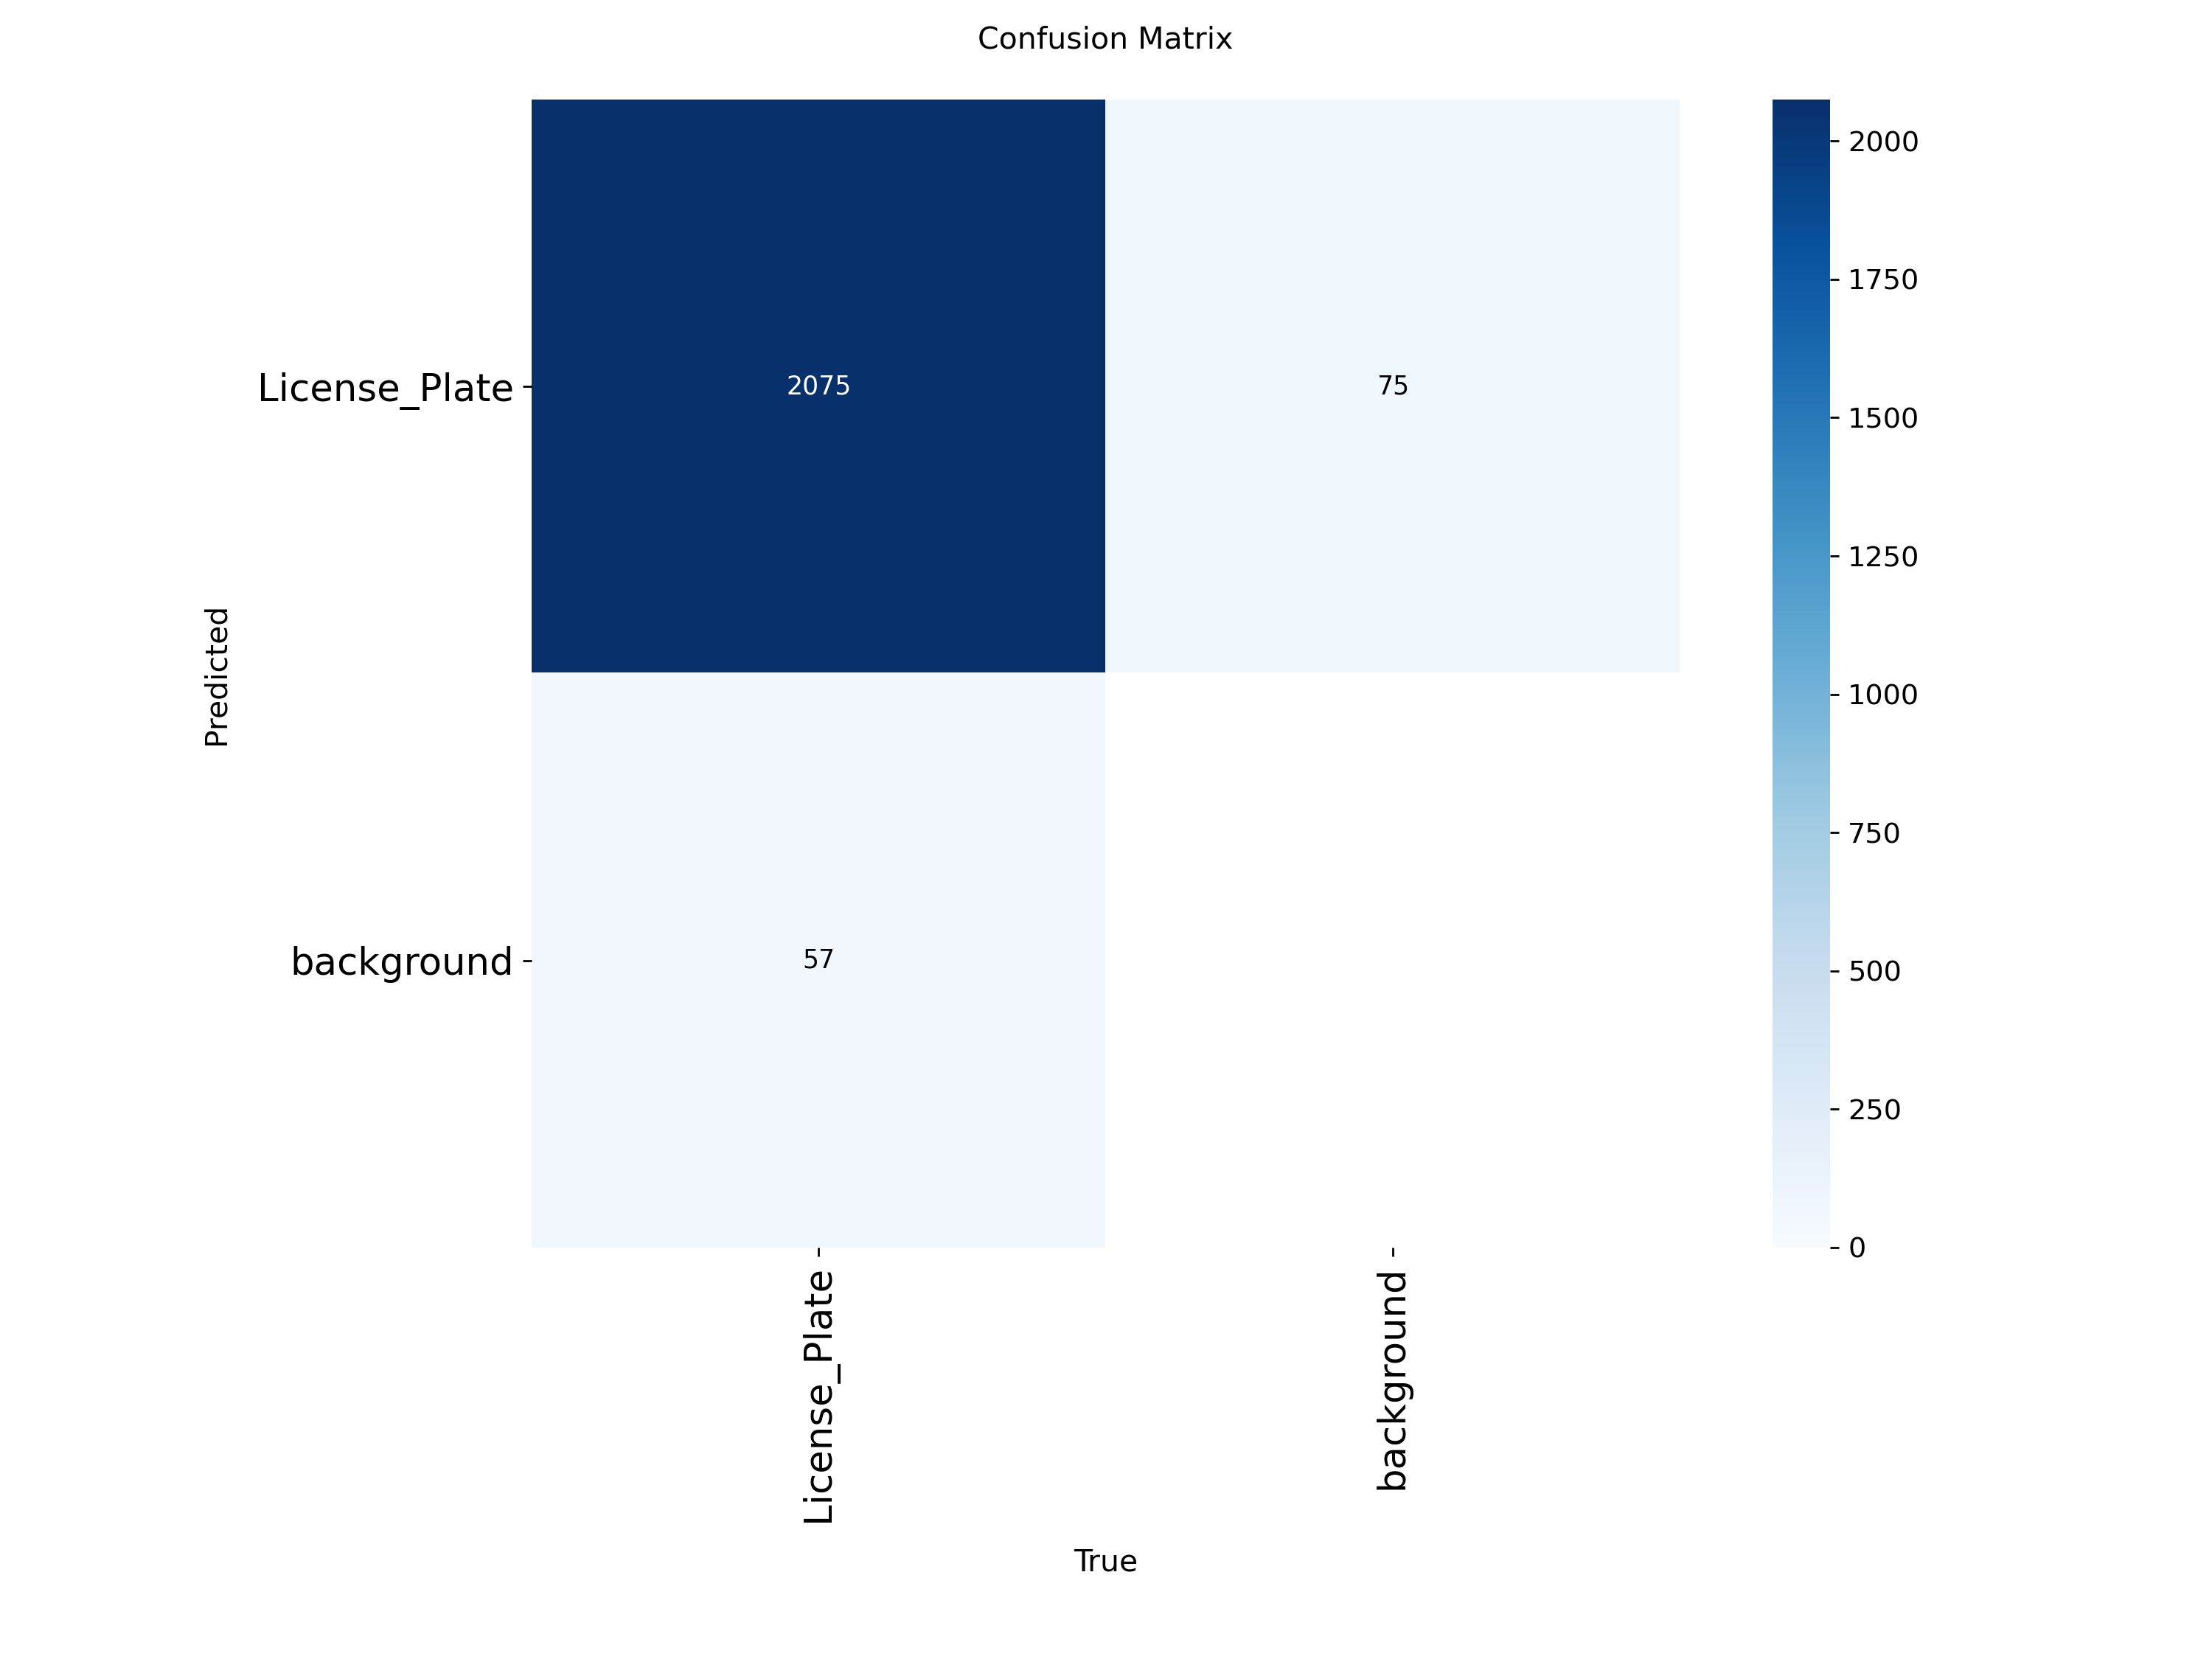

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/confusion_matrix.png', width=900)

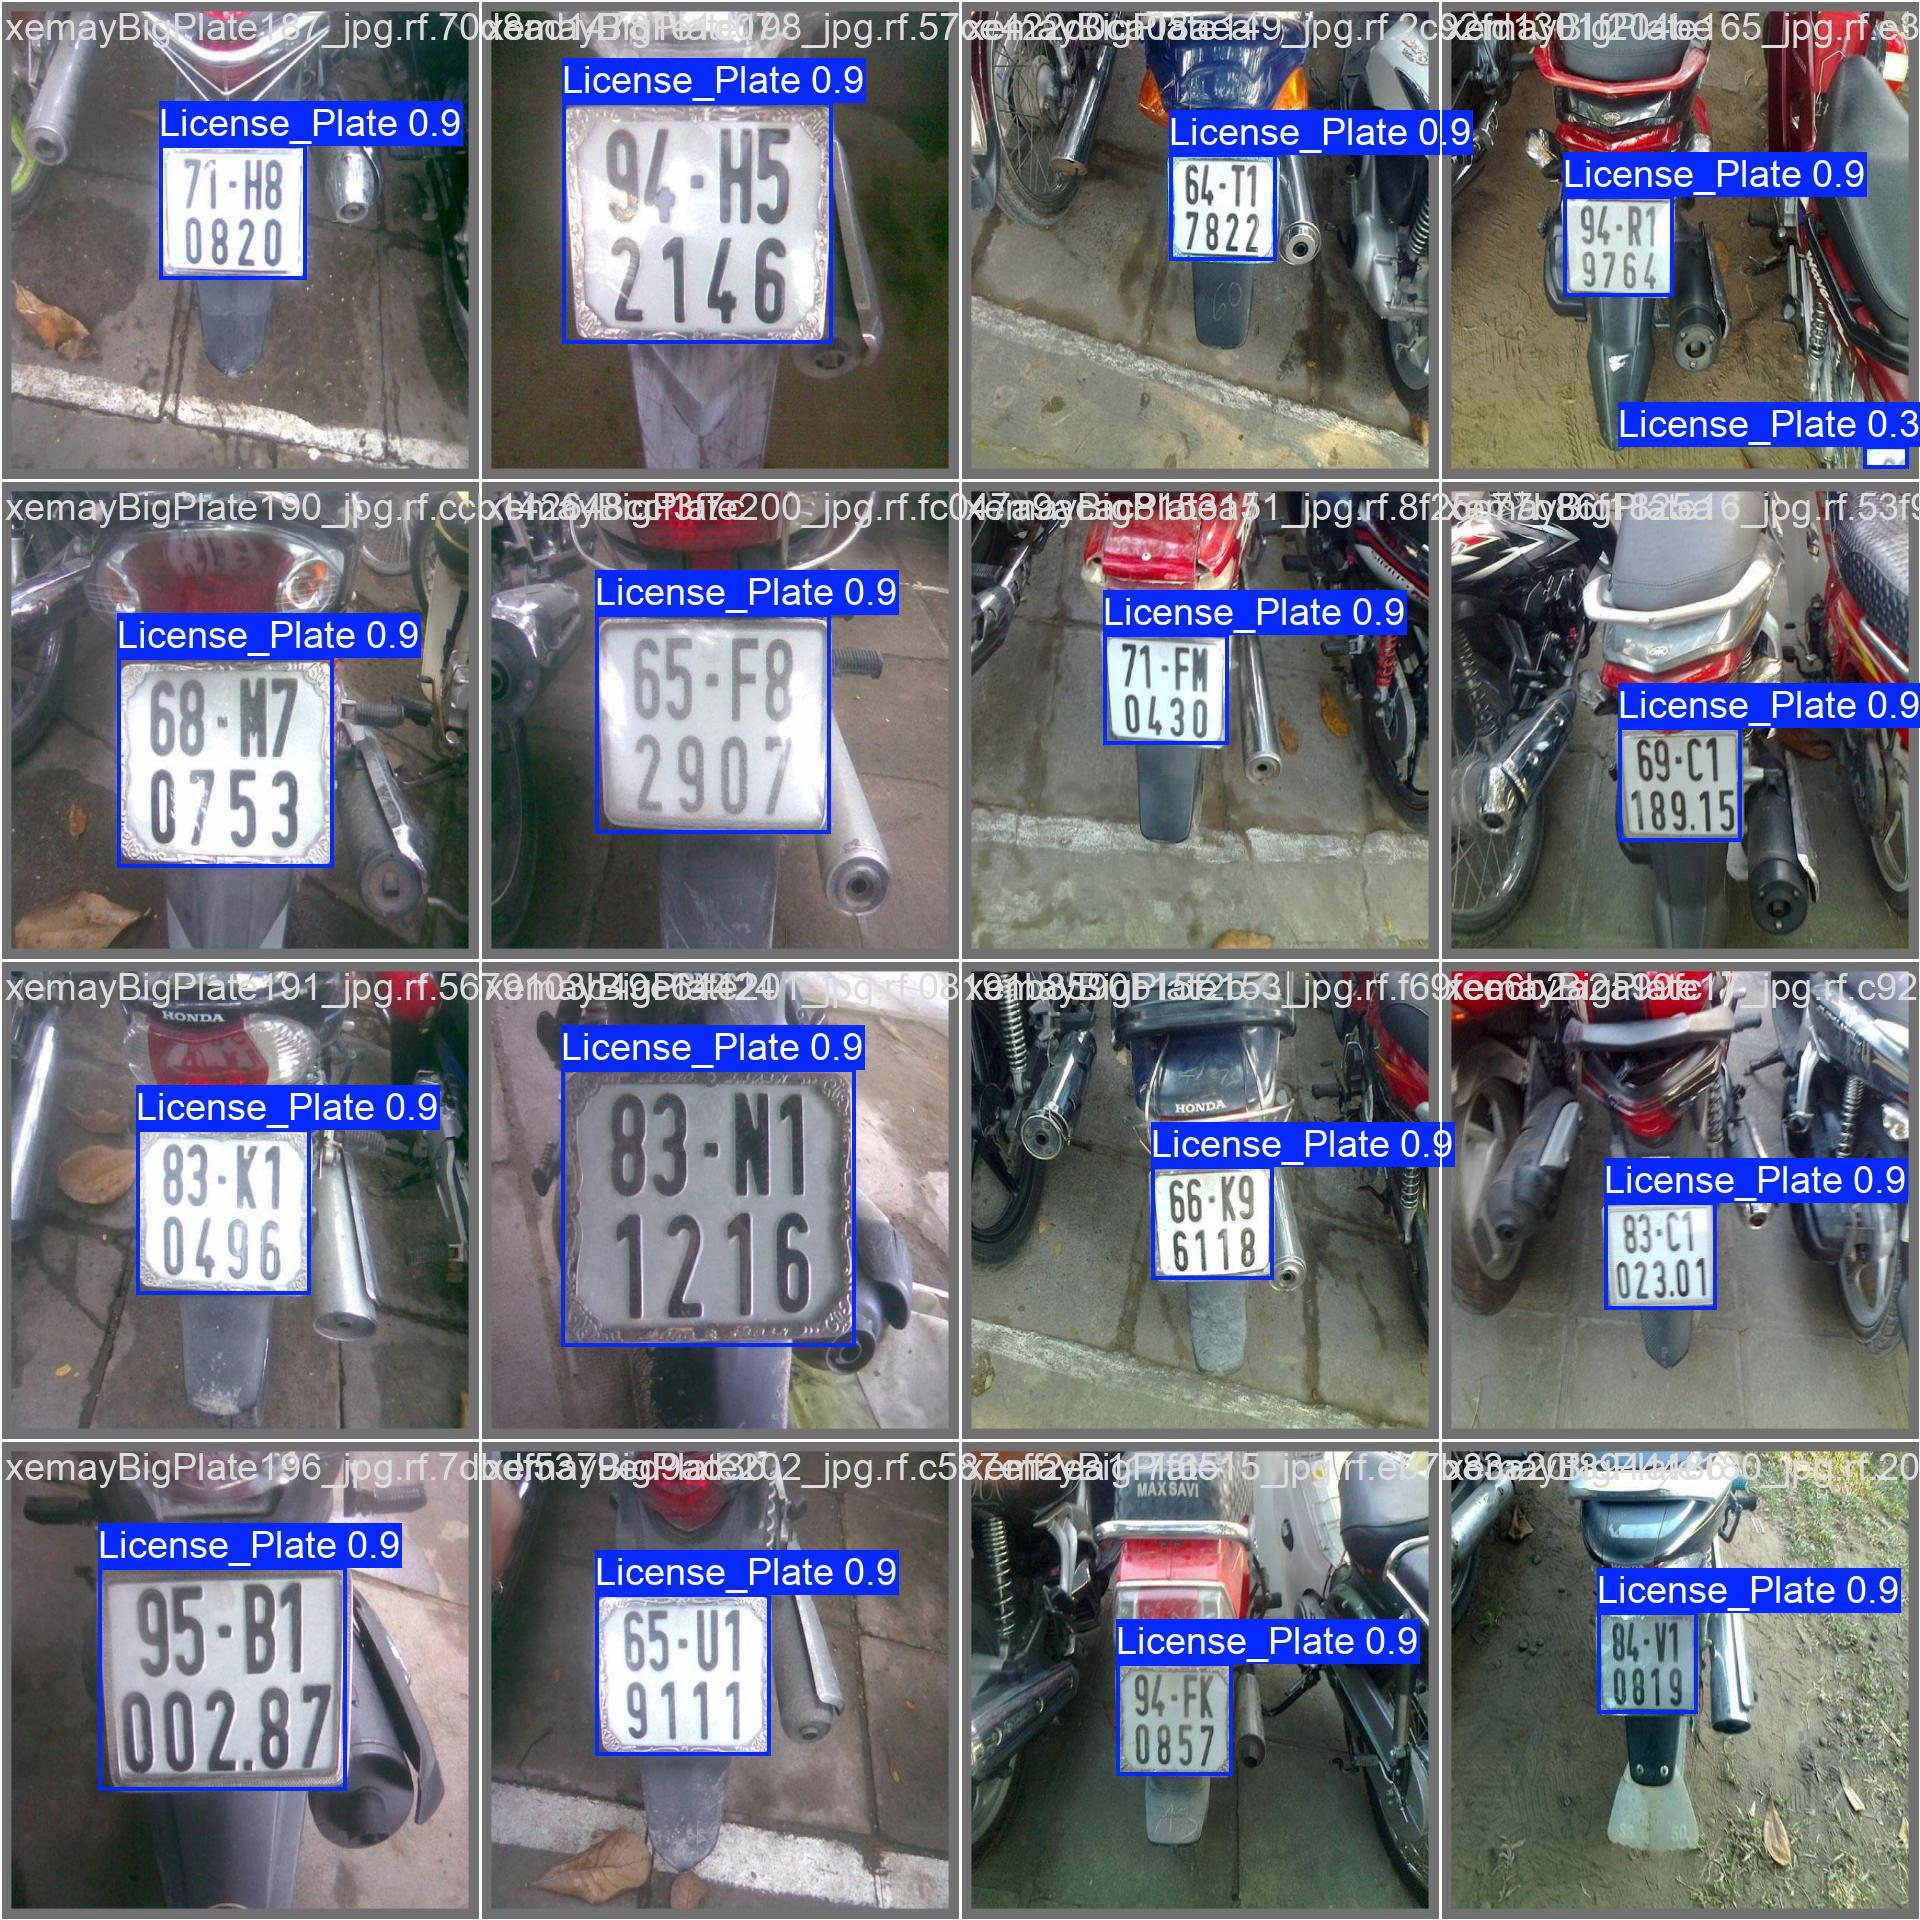

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/val_batch0_pred.jpg', width=900)

In [ ]:
model.val(data="/content/License-Plate-Recognition-4/data.yaml", split="test", verbose=True)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1128.5±357.0 MB/s, size: 39.2 KB)
val: Scanning /content/License-Plate-Recognition-4/test/labels.cache... 1019 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1019/1019 774.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 4.6it/s 13.8s
                   all       1019       1048       0.99      0.968      0.986      0.712
Speed: 2.1ms preprocess, 6.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val2


# Prediction on Test Images

In [ ]:
results = model.predict(
    source=f"/content/License-Plate-Recognition-4/test/images",
    conf=0.5,
    save=True,
    project="runs/detect",
    name="test"
)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1019 /content/License-Plate-Recognition-4/test/images/0002a5b67e5f0909_jpg.rf.07ca41e79eb878b14032f650f34d0967.jpg: 640x640 2 License_Plates, 11.2ms
image 2/1019 /content/License-Plate-Recognition-4/test/images/000812dcf304a8e7_jpg.rf.559f904bc045f68ee947796a1b561d8f.jpg: 640x640 1 License_Plate, 11.2ms
image 3/1019 /content/License-Plate-Recognition-4/test/images/0010f4c10f7ab07e_jpg.rf.92344aa620e23aacc490273e32343595.jpg: 640x640 1 License_P

,,,
,,,
,,,

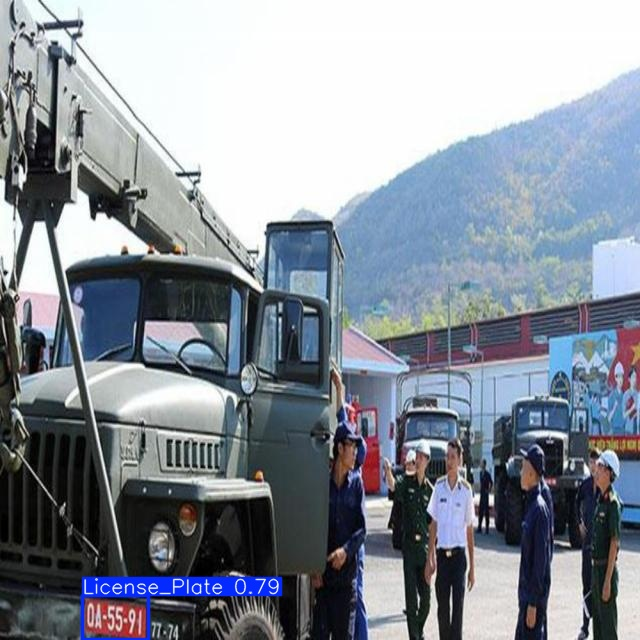
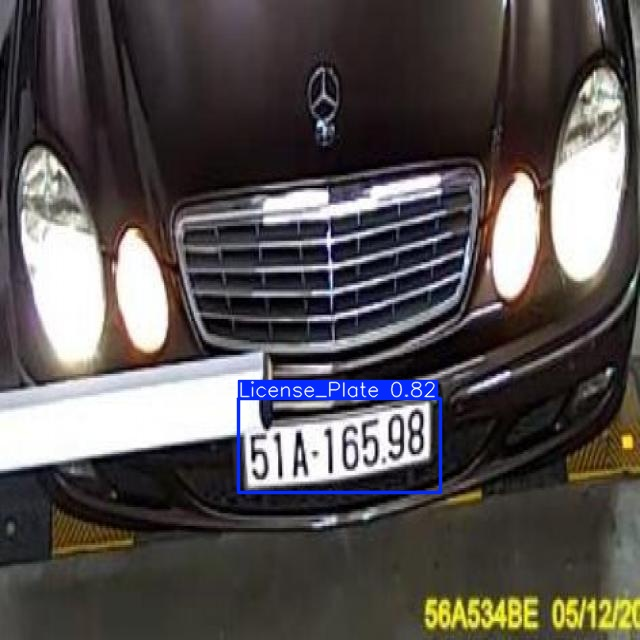
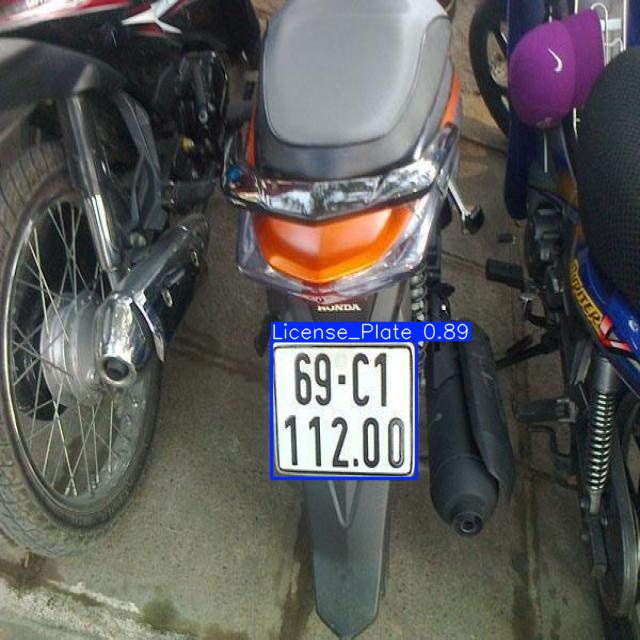
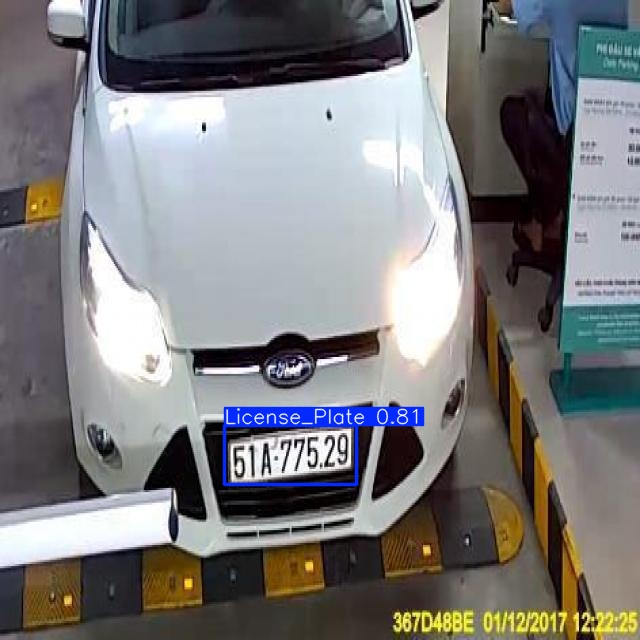
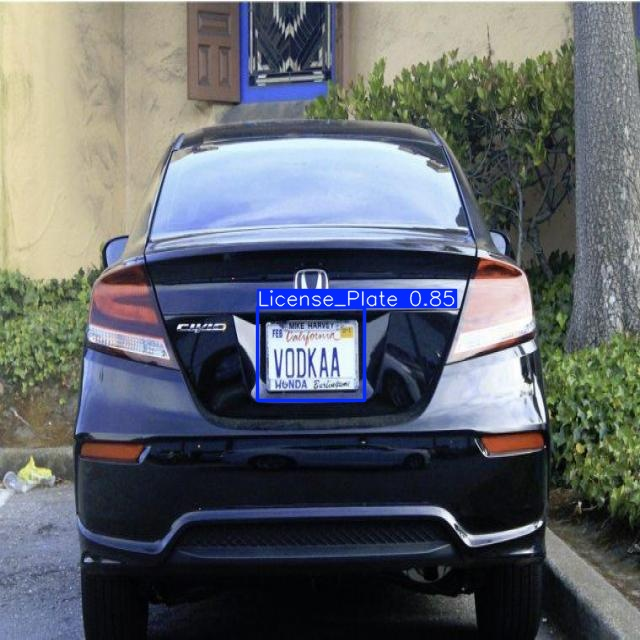
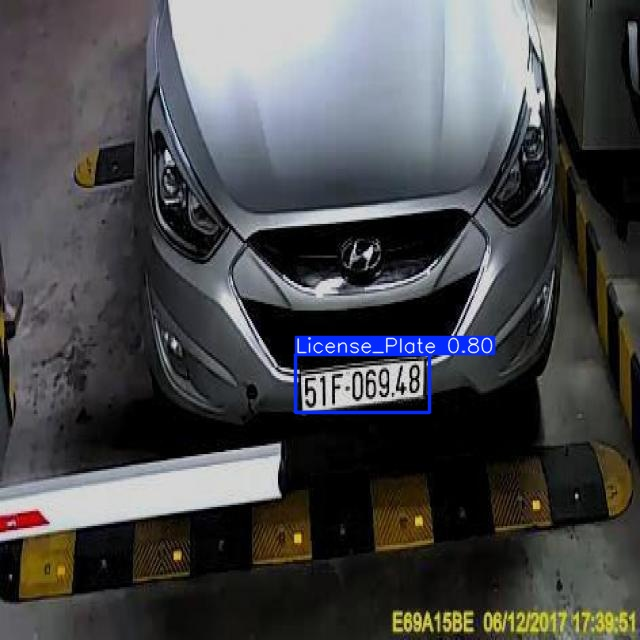
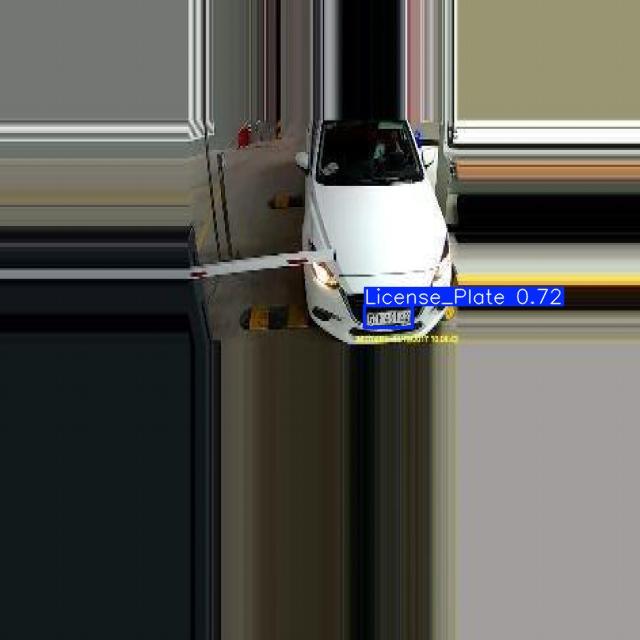
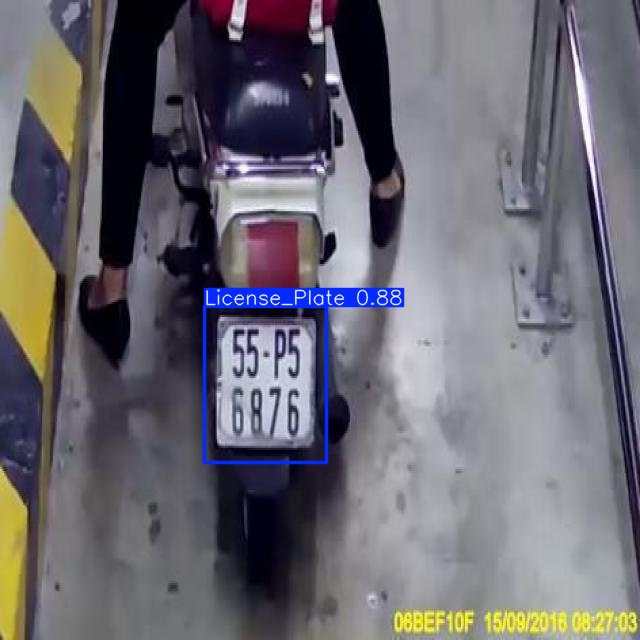
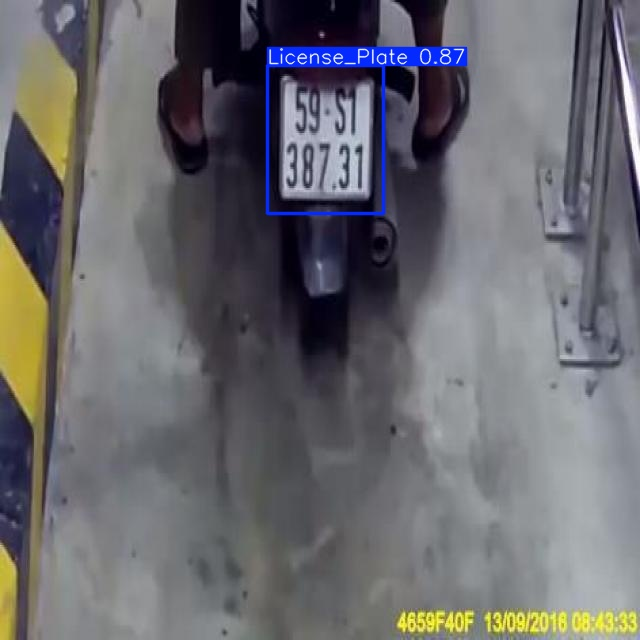
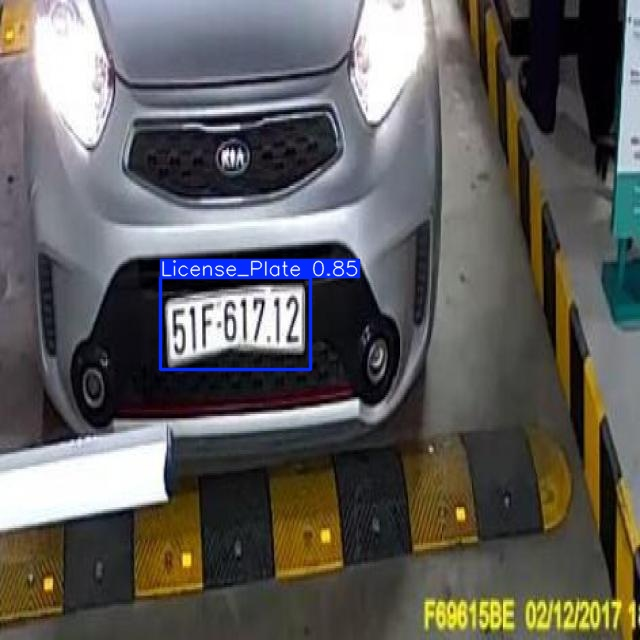
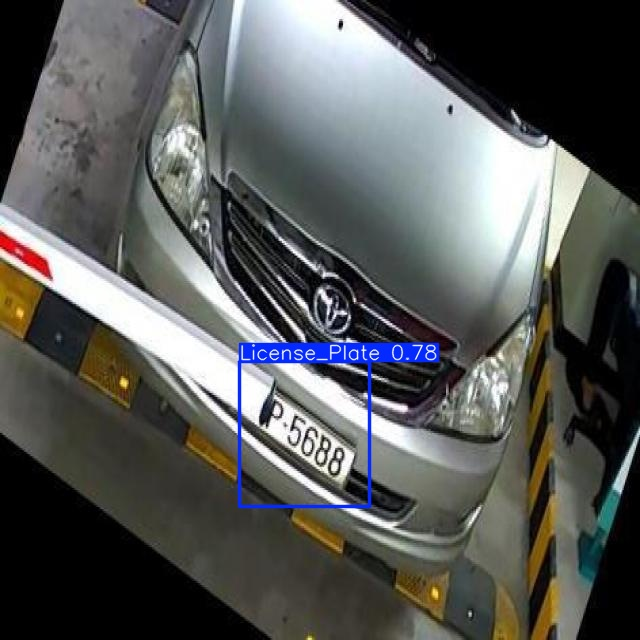
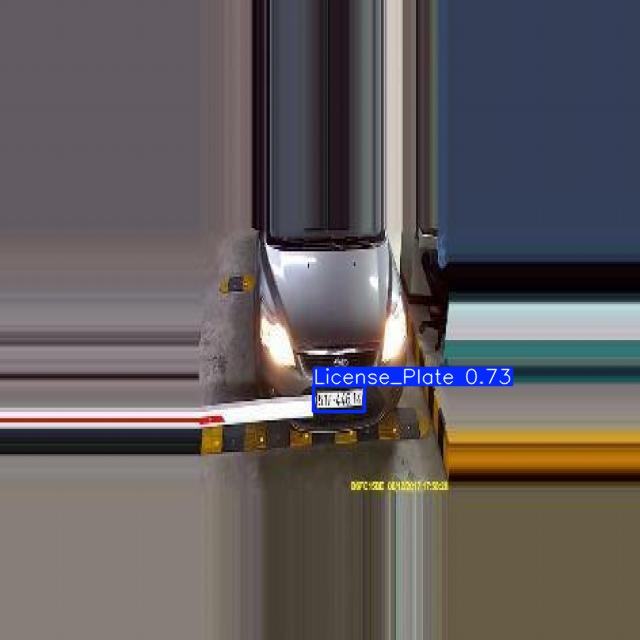

In [ ]:
def img_to_base64(img_path):
    with open(img_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
        return f'<img src="data:image/jpg;base64,{b64}" width="200"/>'

latest_folder = max(glob.glob('/content/runs/detect/test/'), key=os.path.getmtime)
images = glob.glob(f'{latest_folder}/*.jpg')[:12]

imgs_per_row = 4
html = "<table>"
for i in range(0, len(images), imgs_per_row):
    html += "<tr>"
    for img_path in images[i:i+imgs_per_row]:
        html += f"<td>{img_to_base64(img_path)}</td>"
    html += "</tr>"
html += "</table>"

display(HTML(html))